# Hallgren's Algorithm for Pell's Equation

Use quantum Fourier sampling to estimate a real period associated with
Pell's equation, then recover and verify a unit by classical arithmetic.

[The problem](#problem) · [Quantum section](#quantum) ·
[Classical section](#classical) · [Scope and cost](#cost)

The notebook explains Hallgren's algorithm and implements its
real-period sampling and recovery mechanism for small examples.
The Qiskit oracle is compiled from explicit ideal reductions determined
by the input $d$. It does not receive the regulator or a precomputed Pell
solution. Enumerating these reductions and compiling a lookup circuit
are demonstration techniques, not a polynomial-time implementation of
Hallgren's arithmetic oracle.

<a id="problem"></a>
## 1. The problem

For a positive nonsquare integer $d$, Pell's equation is

$$
X^2-dY^2=1.
$$

We seek its fundamental positive solution, the one with the smallest
$X>1$ and $Y>0$. Every other positive solution is obtained from

$$
X_k+Y_k\sqrt d=(X_1+Y_1\sqrt d)^k,\qquad k\geq1.
$$

A crucial issue is the output size. The fundamental solution can require
exponentially many bits in the input length $\log d$. Hallgren's
polynomial-time result therefore concerns an approximation to a logarithm,
with classical refinement or compact representations. It does not
promise to print arbitrarily large $X_1$ and $Y_1$ in polynomial time.

The small examples below do print explicit integer solutions and check
their equations exactly.

### Units, norms, and the regulator

Work in the quadratic order

$$
\mathcal O=\mathbb Z[\sqrt d]
=\{u+v\sqrt d:u,v\in\mathbb Z\},
\qquad \Delta=4d.
$$

For $\alpha=u+v\sqrt d$, its conjugate is $\bar\alpha=u-v\sqrt d$
and its norm is

$$
\operatorname{Nm}(\alpha)=\alpha\bar\alpha=u^2-dv^2.
$$

The units of $\mathcal O$ have norm $1$ or $-1$. There is a smallest
positive unit $\epsilon>1$, and the positive units are its integer
powers. Define the regulator by

$$
R=\log\epsilon.
$$

If $\operatorname{Nm}(\epsilon)=1$, the unit itself gives the fundamental
Pell solution. If its norm is $-1$, use $\epsilon^2$ instead.
Thus the logarithm of the fundamental norm-$1$ solution is either
$R$ or $2R$.

This convention matters. We use the regulator of $\mathbb Z[\sqrt d]$,
which need not be the maximal order when $d\equiv1\pmod4$.
For instance, $2+\sqrt5$ is the fundamental unit of this order, and
its square $9+4\sqrt5$ solves Pell's equation.

See [Hallgren's paper](https://public.csusm.edu/ssharif/crypto/Hallgren-Pell.pdf)
for the algorithm over quadratic orders.

### A hidden subgroup of the real line

An ideal is an additive subgroup closed under multiplication by elements
of the order. A fractional principal ideal has the form
$I=\beta\mathcal O$ with nonzero $\beta\in\mathbb Q(\sqrt d)$.
Changing its generator by a unit leaves the ideal unchanged.

Using the distance convention

$$
\delta(\beta\mathcal O)
=\frac12\log\left|\frac{\beta}{\bar\beta}\right|\pmod R,
$$

multiplication of generators adds distances. The factor $1/2$ ensures
that multiplying by a positive unit $\epsilon$ changes the unreduced
distance by $R$.

The finitely many reduced principal ideals form a cycle, with increasing
distances on a circle of circumference $R$. For a real input $z$, let
$I_z$ be the reduced ideal immediately to its left, and let $u_z$ be
the distance from that occurrence of the ideal to $z$. Then

$$
f(z)=(I_z,u_z),
\qquad
f(z)=f(w)\ \Longleftrightarrow\ z-w\in R\mathbb Z.
$$

The residual distance $u_z$ distinguishes points between neighboring
ideals. The exact hidden subgroup is $R\mathbb Z$ in the additive group
$\mathbb R$. Since $R$ is generally irrational, this is beyond the
finite abelian setting.

<a id="quantum"></a>
## 2. Quantum section

### Discretize without replacing the real period by an integer

Choose an integer sampling density $B\geq2\sqrt\Delta$, a finite input
range $0\leq j<Q$ with $Q=2^n$, and a small rational shift $\tau$.
Evaluate the ideal function at $z=j/B+\tau$ and keep the label

$$
f_{B,\tau}(j)=
\left(I_z,\left\lfloor B u_z\right\rfloor\right).
$$

The scaled real period is $S=BR$. We do not replace it by
$\lfloor S\rfloor$ or $\lceil S\rceil$. On a suitable fraction of
offsets, repeated labels occur at indices separated by rounded
multiples of $S$. This is the pseudoperiodicity used in Hallgren's proof.

The full algorithm chooses the shift and precision to control errors
near ideal boundaries. Our small example uses $\tau=1/(7B)$ and checks
that its complete table agrees at two decimal precisions. This is a
numerical stability check, not an interval-arithmetic proof or the full
random-shift analysis.

### Fourier sampling of an approximately periodic fiber

Compute the labels reversibly with

$$
U_f\lvert j\rangle\lvert w\rangle
=\lvert j\rangle\lvert w\mathbin{\oplus}\operatorname{enc}(f_{B,\tau}(j))\rangle.
$$

Hadamards, this oracle, and an inverse QFT prepare

$$
\frac1{\sqrt Q}\sum_{j=0}^{Q-1}\lvert j,f_{B,\tau}(j)\rangle
\ \longmapsto\
\frac1Q\sum_{y=0}^{Q-1}\sum_{j=0}^{Q-1}
e^{-2\pi i jy/Q}\lvert y,f_{B,\tau}(j)\rangle.
$$

Let $T_\lambda=\{j:f_{B,\tau}(j)=\lambda\}$. Measuring only the input
register has the exact finite-circuit distribution

$$
\Pr(Y=y)=\frac1{Q^2}
\sum_\lambda\left|\sum_{j\in T_\lambda}e^{-2\pi i jy/Q}\right|^2.
$$

On a good fiber, write its points as $j_k=j_0+kS+e_k$, with bounded
rounding offsets $e_k$. Its Fourier amplitude contains

$$
e^{-2\pi i j_0y/Q}
\sum_k e^{-2\pi i kSy/Q}e^{-2\pi i e_ky/Q}.
$$

Near $y=hQ/S$, the first phase factor inside the sum aligns. For
sufficiently low frequencies, the rounding factors do not destroy this
interference. Thus useful samples approximately satisfy

$$
y\approx\frac{hQ}{BR}.
$$

This relation holds for useful outcomes, not every shot. Hallgren's
analysis controls the probability of obtaining them and the precision
needed for recovery.

### Explicit ideal reductions for the small oracle

The following continued-fraction reduction gives concrete ideal labels.
Write

$$
\alpha_i=\frac{P_i+\sqrt d}{q_i},
\qquad
I_i=\mathbb Z+\alpha_i\mathbb Z.
$$

Start with $P_0=\lfloor\sqrt d\rfloor$, $q_0=1$, so $I_0=\mathcal O$.
For these reduced quadratic irrationals, let

$$
a_i=\left\lfloor\frac{P_i+\sqrt d}{q_i}\right\rfloor,\qquad
P_{i+1}=a_iq_i-P_i,\qquad
q_{i+1}=\frac{d-P_{i+1}^2}{q_i}.
$$

Then $\alpha_{i+1}=1/(\alpha_i-a_i)$ and
$I_{i+1}=\alpha_{i+1}I_i$. The last identity follows by multiplying
the basis $(1,\alpha_i)$ by $\alpha_{i+1}$ and using
$\alpha_i\alpha_{i+1}=a_i\alpha_{i+1}+1$.

Accumulate the positive distance increments

$$
\delta_{i+1}-\delta_i
=\frac12\log\left|\frac{\alpha_{i+1}}{\bar\alpha_{i+1}}\right|
=\frac12\log\frac{\sqrt d+P_{i+1}}{\sqrt d-P_{i+1}}.
$$

One complete principal cycle advances by $R$. The code walks forward
only as far as the finite input range requires. It does not first find
the cycle length or the regulator.

The normalized ideal label is $(P_i\bmod q_i,q_i)$. The residual-distance
bucket is included in the oracle label as well.

In [1]:
# Run this only if the dependencies are missing.
# %pip install -r requirements.txt

In [2]:
from collections import Counter
from decimal import Decimal, localcontext
from fractions import Fraction
from math import isqrt

import numpy as np
import matplotlib.pyplot as plt
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit.primitives import StatevectorSampler
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)

Qiskit: 2.5.2
NumPy: 2.5.3


In [3]:
def check_d(d):
    if type(d) is not int or d < 2 or isqrt(d)**2 == d:
        raise ValueError("d must be an integer at least 2 and not a perfect square.")


def next_ideal(d, P, q):
    a = (isqrt(d) + P) // q
    next_P = a * q - P
    numerator = d - next_P * next_P
    if numerator <= 0 or numerator % q:
        raise ArithmeticError("Invalid ideal-reduction state.")
    return next_P, numerator // q


def ideal_walk(d, limit, precision=60, max_steps=20000):
    '''Forward reduction records (P, q, unreduced distance), with no known R.'''
    check_d(d)
    if limit < 0 or precision < 30 or max_steps < 1:
        raise ValueError("Require a nonnegative limit and sufficient precision and steps.")
    with localcontext() as ctx:
        ctx.prec = precision
        root = Decimal(d).sqrt()
        P, q, distance = isqrt(d), 1, Decimal(0)
        records = [(P, q, distance)]
        for _ in range(max_steps):
            P, q = next_ideal(d, P, q)
            distance += ((root + P) / (root - P)).ln() / 2
            records.append((P, q, distance))
            if distance > limit:
                return records
    raise RuntimeError("Ideal-walk budget exhausted.")


def label_table_at_precision(d, B, Q, precision):
    with localcontext() as ctx:
        ctx.prec = precision
        shift = Decimal(1) / (7 * B)
        records = ideal_walk(d, Decimal(Q - 1) / B + shift, precision)
        cursor = 0
        labels = []
        for j in range(Q):
            z = Decimal(j) / B + shift
            while records[cursor + 1][2] <= z:
                cursor += 1
            P, q, distance = records[cursor]
            bucket = int((z - distance) * B)  # Floor for a nonnegative residual.
            labels.append((P % q, q, bucket))
    return labels


def make_pell_table(d, B, Q):
    '''Compile a small discretized ideal function directly from d.'''
    check_d(d)
    if type(B) is not int or B < 1 or B * B < 16 * d:
        raise ValueError("Require integer B >= 4*sqrt(d).")
    if type(Q) is not int or Q < 8 or Q > 512 or Q & (Q - 1):
        raise ValueError("Use a power-of-two Q between 8 and 512 in this demonstration.")
    low = label_table_at_precision(d, B, Q, 40)
    labels = label_table_at_precision(d, B, Q, 80)
    if low != labels:
        raise ArithmeticError("Labels are unstable. Increase precision or change the shift.")
    encodings = {}
    values = [encodings.setdefault(label, len(encodings)) for label in labels]
    return values, labels

### Compile the oracle as a reversible Boolean circuit

Each output bit is a Boolean function of the input bits. The code
converts its truth table to algebraic normal form over $\mathbb F_2$:

$$
g(j_0,\ldots,j_{n-1})
=\bigoplus_{A\subseteq\{0,\ldots,n-1\}}
c_A\prod_{k\in A}j_k.
$$

A coefficient $c_A=1$ becomes a NOT gate on that output bit controlled
by the input bits in $A$. The empty set gives an ordinary NOT gate.
This implements XOR evaluation for every initial output state, and
applying the oracle twice restores the output.

The compilation is exponential in $n$ because it uses all $Q=2^n$
table entries. It makes the small hiding function inspectable.
Hallgren's efficient oracle instead uses ideal composition, reduction,
and distance arithmetic coherently, with temporary data uncomputed.

In [4]:
def lookup_oracle(values):
    Q = len(values)
    if Q < 2 or Q > 512 or Q & (Q - 1):
        raise ValueError("The table length must be a power of two at most 512.")
    if any(type(value) is not int or value < 0 for value in values):
        raise ValueError("Table labels must be nonnegative integers.")
    n = (Q - 1).bit_length()
    m = max(1, max(values).bit_length())
    if n + m > 16:
        raise ValueError("This local simulation is limited to 16 total qubits.")
    # Packed output words undergo the Boolean Möbius transform simultaneously.
    coefficients = list(values)
    for bit in range(n):
        for mask in range(Q):
            if mask & (1 << bit):
                coefficients[mask] ^= coefficients[mask ^ (1 << bit)]
    circuit = QuantumCircuit(n + m, name="pell_lookup")
    for mask, word in enumerate(coefficients):
        controls = [bit for bit in range(n) if mask & (1 << bit)]
        for out_bit in range(m):
            if (word >> out_bit) & 1:
                if controls:
                    circuit.mcx(controls, n + out_bit)
                else:
                    circuit.x(n + out_bit)
    return circuit, n, m


def fourier_sampling_circuit(values):
    oracle, n, m = lookup_oracle(values)
    inputs = QuantumRegister(n, "input")
    output = QuantumRegister(m, "label")
    measured = ClassicalRegister(n, "frequency")
    circuit = QuantumCircuit(inputs, output, measured)
    circuit.h(inputs)
    circuit.append(oracle.to_gate(label=r"$U_f$"), [*inputs, *output])
    iqft = QFTGate(n).inverse().definition.to_gate(label=r"$F_Q^\dagger$")
    circuit.append(iqft, inputs)
    circuit.measure(inputs, measured)
    return circuit, len(oracle.data)


def sample_frequencies(values, shots=1024, seed=2026):
    if type(shots) is not int or shots < 1:
        raise ValueError("shots must be a positive integer.")
    circuit, terms = fourier_sampling_circuit(values)
    result = StatevectorSampler(seed=seed).run([circuit], shots=shots).result()[0]
    samples = [int(bits, 2) for bits in result.data.frequency.get_bitstrings()]
    return samples, circuit, terms

### Quantum example

Use $d=3$, $B=8$, and $Q=512$. A supplied coarse bound $S<12$ gives
$Q\geq3(12)^2$, the scale used in the real-period recovery argument.
The oracle builder receives only $d$, $B$, and $Q$. This bound is used
later to limit classical candidates.

The circuit below shows the Hadamards, the compiled ideal-function
oracle, and the inverse QFT. Input bit $j$ is measured into classical
bit $j$, so Qiskit's displayed bitstrings can be parsed directly as
binary integers.

d = 3, B = 8, Q = 512
Distinct encoded labels: 12
Controlled-NOT terms in the lookup oracle: 840
Most frequent outcomes: [(0, 82), (415, 77), (366, 76), (97, 70), (463, 61), (146, 58), (269, 47), (243, 44)]


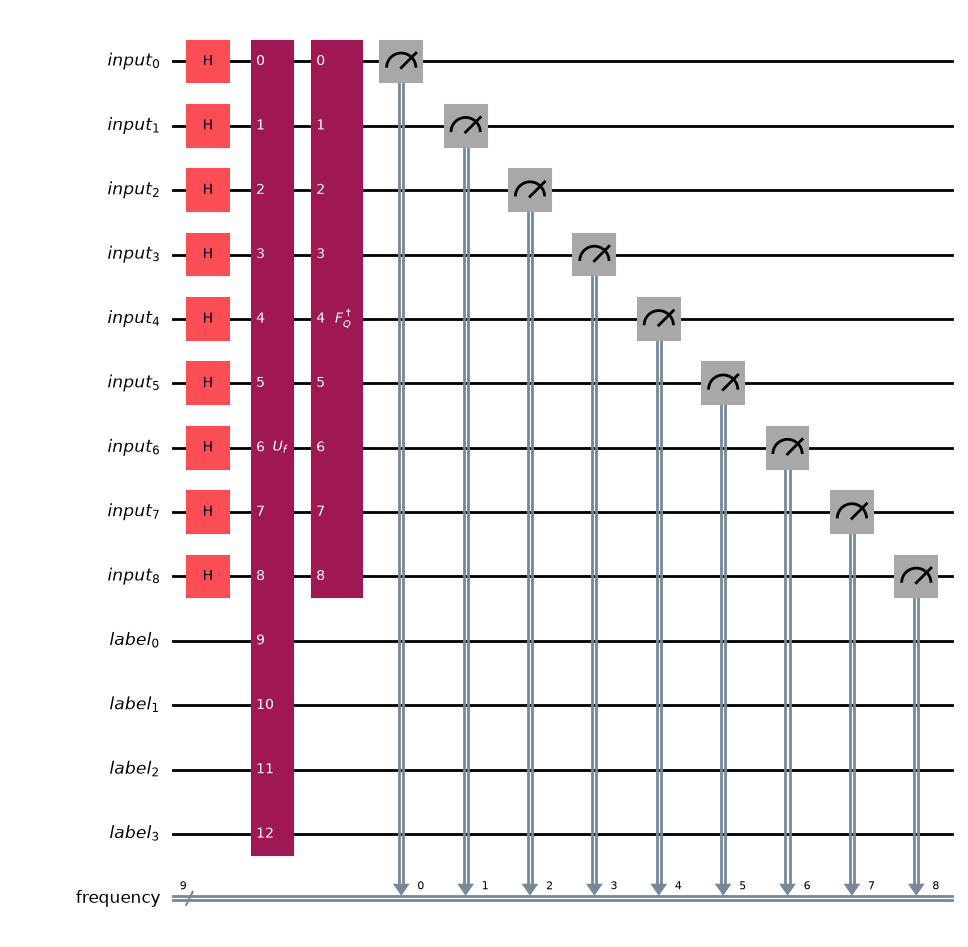

In [5]:
d, B, Q, scaled_bound = 3, 8, 512, 12
values, ideal_labels = make_pell_table(d, B, Q)
samples, circuit, oracle_terms = sample_frequencies(values, shots=1024, seed=2026)
print(f"d = {d}, B = {B}, Q = {Q}")
print("Distinct encoded labels:", len(set(values)))
print("Controlled-NOT terms in the lookup oracle:", oracle_terms)
print("Most frequent outcomes:", Counter(samples).most_common(8))
display(circuit.draw("mpl", fold=-1, style={"fontsize": 10}))
plt.close("all")

The finite distribution is symmetric under $y\mapsto Q-y$, because
each fiber has a real indicator vector. We combine these mirrored
outcomes in the plot and in the classical recovery. Zero carries no
useful frequency ratio and is discarded during recovery.

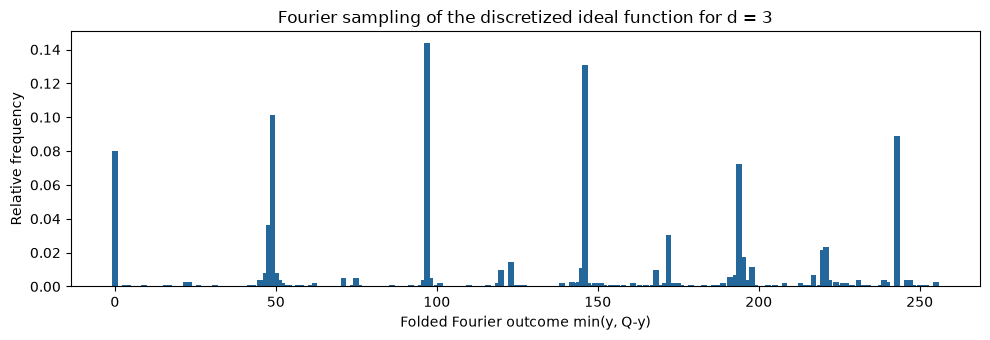

In [6]:
folded = Counter(min(y, Q - y) for y in samples)
frequencies = np.array(sorted(folded))
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(frequencies, [folded[y] / len(samples) for y in frequencies],
       width=1.8, color="#24689b")
ax.set(xlabel="Folded Fourier outcome min(y, Q-y)", ylabel="Relative frequency",
       title="Fourier sampling of the discretized ideal function for d = 3")
fig.tight_layout()
plt.show()

<a id="classical"></a>
## 3. Classical section

### Recover the ratio of two unknown harmonics

For two useful positive frequencies, write

$$
y_1\approx\frac{hQ}{BR},
\qquad
y_2\approx\frac{kQ}{BR}.
$$

Their ratio approximates $h/k$, so examine the continued-fraction
convergents of $y_1/y_2$. When $h$ and $k$ are coprime and the samples
are sufficiently accurate, the reduced fraction reveals both indices.
It then gives the regulator estimate

$$
\widehat R=\frac{hQ}{B y_1}.
$$

This differs from integer order finding. The denominator of $y/Q$
cannot directly represent the irrational period $BR$.

For a bound $S<M$ and sufficiently good low-frequency samples,
$Q\geq3M^2$ makes the relevant ratio a convergent and gives an estimate
of the scaled period within an additive constant. Hallgren's algorithm
tests these candidates using the ideal infrastructure.
Our code tests estimates within distance $1/B$ of a unit return.

With inaccurate samples, unrelated convergents may occur. The bound
and the continued fraction alone do not establish correctness.

In [7]:
def convergents(a, b):
    if type(a) is not int or type(b) is not int or a < 0 or b <= 0:
        raise ValueError("Require nonnegative integer a and positive integer b.")
    prev_num, num, prev_den, den = 0, 1, 1, 0
    while b:
        quotient, remainder = divmod(a, b)
        prev_num, num = num, quotient * num + prev_num
        prev_den, den = den, quotient * den + prev_den
        yield num, den
        a, b = b, remainder

### Refine near a candidate and verify the unit exactly

Maintain an exact generator $\beta=u+v\sqrt d$ while walking through
the reduction steps. Multiplication by
$\alpha_{i+1}=(P_{i+1}+\sqrt d)/q_{i+1}$ updates

$$
u'=\frac{P_{i+1}u+dv}{q_{i+1}},
\qquad
v'=\frac{u+P_{i+1}v}{q_{i+1}}.
$$

When the ideal returns to $\mathcal O$, both coefficients are integers
and $u^2-dv^2=\pm1$. A nearby return refines the estimated distance to
$\log(u+v\sqrt d)$.

The small verifier below walks from the origin to the candidate.
This is deliberately explicit and can be slow for large distances.
Hallgren's polynomial-time verifier reaches the neighborhood using
ideal arithmetic, rather than enumerating the full path.

A returned unit can be a higher power of the fundamental unit. Across
the bounded sample pairs, keep the smallest verified positive unit.
If the useful samples reveal the fundamental return, it is selected.
This implementation certifies the norm equation, but does not claim a
general fundamental-unit certificate or Hallgren's full success bound
for these demonstration parameters.

In [8]:
def unit_near(d, estimate, tolerance, precision=80, max_steps=20000):
    '''Small-instance candidate refinement by an explicit forward walk.'''
    check_d(d)
    estimate, tolerance = Fraction(estimate), Fraction(tolerance)
    if estimate <= 0 or tolerance <= 0:
        return None
    with localcontext() as ctx:
        ctx.prec = precision
        target = Decimal(estimate.numerator) / estimate.denominator
        radius = Decimal(tolerance.numerator) / tolerance.denominator
        root = Decimal(d).sqrt()
        P, q, distance = isqrt(d), 1, Decimal(0)
        u, v = Fraction(1), Fraction(0)
        for _ in range(max_steps):
            P, q = next_ideal(d, P, q)
            u, v = (P * u + d * v) / q, (u + P * v) / q
            distance += ((root + P) / (root - P)).ln() / 2
            if distance > target + radius:
                return None
            if q == 1 and abs(distance - target) <= radius:
                if u.denominator != 1 or v.denominator != 1:
                    raise ArithmeticError("A unit return has nonintegral coefficients.")
                x, y = int(u), int(v)
                norm = x * x - d * y * y
                if norm not in (-1, 1) or x <= 0 or y <= 0:
                    raise ArithmeticError("The proposed unit failed exact verification.")
                return {"unit": (x, y), "norm": norm, "regulator_candidate": distance}
    raise RuntimeError("Candidate-refinement budget exhausted.")


def recover_regulator(samples, d, B, Q, scaled_bound):
    '''Generate candidates from disjoint pairs and retain the smallest verified unit.'''
    check_d(d)
    if (type(B) is not int or B < 1 or type(Q) is not int or Q < 8
            or Q & (Q - 1) or type(scaled_bound) is not int or scaled_bound < 1
            or Q < 3 * scaled_bound**2):
        raise ValueError("Require valid B, power-of-two Q, and Q >= 3*scaled_bound**2.")
    samples = list(samples)
    if len(samples) < 2 or len(samples) % 2:
        raise ValueError("Supply a positive even number of outcomes.")
    if any(type(y) is not int or not 0 <= y < Q for y in samples):
        raise ValueError("Each outcome must be an integer between 0 and Q-1.")
    cache = {}
    accepted = []
    for index in range(0, len(samples), 2):
        first, second = samples[index:index + 2]
        c, e = sorted((min(first, Q - first), min(second, Q - second)))
        if c == 0:
            continue
        for h, k in convergents(c, e):
            if h == 0 or k >= scaled_bound:
                continue
            estimate = Fraction(h * Q, B * c)
            if not 0 < estimate < Fraction(scaled_bound, B):
                continue
            if estimate not in cache:
                cache[estimate] = unit_near(d, estimate, Fraction(1, B))
            if cache[estimate] is not None:
                accepted.append({**cache[estimate], "estimate": estimate,
                                 "frequencies": (c, e), "harmonic_ratio": (h, k)})
    if not accepted:
        raise RuntimeError("No verified unit found. Increase the sample or period-bound budget.")
    # For positive units x+y*sqrt(d)>1 with y>0, y increases with the unit.
    best = min(accepted, key=lambda item: (item["unit"][1], item["unit"][0]))
    return {**best, "tested_estimates": len(cache), "accepted_candidates": len(accepted),
            "fundamental_certified": False}

### Recover the regulator from the Qiskit samples

The samples for $d=3$ contain peaks near $49$ and $97$. Their ratio
has $1/2$ as a convergent, suggesting

$$
\widehat R=\frac{512}{8\cdot49}\approx1.3061.
$$

The infrastructure check refines this estimate to the neighboring unit
return. The full recovery code examines all disjoint pairs and does
not hard-code these two outcomes.

In [9]:
result = recover_regulator(samples, d, B, Q, scaled_bound)
print("Recovered unit candidate:", result["unit"], "with norm", result["norm"])
print("Refined regulator:", f"{result['regulator_candidate']:.16f}")
print("Distinct estimates checked:", result["tested_estimates"])
print("Verified candidate occurrences:", result["accepted_candidates"])
assert result["unit"] == (2, 1)
assert result["unit"][0]**2 - d * result["unit"][1]**2 == 1

Recovered unit candidate: (2, 1) with norm 1
Refined regulator: 1.3169578969248167
Distinct estimates checked: 94
Verified candidate occurrences: 328


### Convert a unit to a Pell solution

For norm $1$, retain the coefficients. For norm $-1$, square the unit:

$$
(u+v\sqrt d)^2=(u^2+dv^2)+(2uv)\sqrt d.
$$

The returned pair is verified with integer arithmetic. It is the
fundamental Pell solution if the recovered unit was fundamental.
Otherwise it remains a valid positive solution.

In [10]:
def pell_from_unit(d, unit):
    check_d(d)
    u, v = unit
    if type(u) is not int or type(v) is not int or u <= 0 or v <= 0:
        raise ValueError("Use positive integer unit coefficients.")
    norm = u * u - d * v * v
    if norm == 1:
        X, Y = u, v
    elif norm == -1:
        X, Y = u * u + d * v * v, 2 * u * v
    else:
        raise ValueError("The coefficients do not describe a norm +/-1 unit.")
    if X * X - d * Y * Y != 1:
        raise ArithmeticError("Pell verification failed.")
    return X, Y

In [11]:
X, Y = pell_from_unit(d, result["unit"])
print(f"d = {d}: X = {X}, Y = {Y}, X^2 - dY^2 = {X*X - d*Y*Y}")

# A second genuine quantum run demonstrates a norm -1 fundamental unit.
values2, _ = make_pell_table(2, 8, 256)
samples2, _, _ = sample_frequencies(values2, shots=512, seed=19)
result2 = recover_regulator(samples2, 2, 8, 256, scaled_bound=8)
pell2 = pell_from_unit(2, result2["unit"])
print("d = 2 unit:", result2["unit"], "norm:", result2["norm"])
print("d = 2 Pell solution after squaring:", pell2)
assert result2["unit"] == (1, 1) and result2["norm"] == -1
assert pell2 == (3, 2)

d = 3: X = 2, Y = 1, X^2 - dY^2 = 1


d = 2 unit: (1, 1) norm: -1
d = 2 Pell solution after squaring: (3, 2)


### An independent classical check for small inputs

For validation, the continued fractions of $\sqrt d$ give the
fundamental unit: inspect the convergents until the norm is $1$ or $-1$.
This routine is entirely classical and can take too many steps for
large inputs. It is not used by the oracle or the Fourier recovery.

Comparing against it establishes that the two displayed quantum examples
found the fundamental unit, rather than merely some unit.

In [12]:
def fundamental_unit_reference(d, max_steps=20000):
    '''Classical continued-fraction reference, used only for checking small examples.'''
    check_d(d)
    a0 = isqrt(d)
    P, q, a = 0, 1, a0
    prev_num, num, prev_den, den = 0, 1, 1, 0
    for _ in range(max_steps):
        prev_num, num = num, a * num + prev_num
        prev_den, den = den, a * den + prev_den
        if num * num - d * den * den in (-1, 1):
            return num, den
        P = a * q - P
        q = (d - P * P) // q
        a = (a0 + P) // q
    raise RuntimeError("Classical reference budget exhausted.")


assert result["unit"] == fundamental_unit_reference(3)
assert result2["unit"] == fundamental_unit_reference(2)
for check in (2, 3, 5, 13, 61):
    unit = fundamental_unit_reference(check)
    solution = pell_from_unit(check, unit)
    print(f"Classical reference d={check}: unit={unit}, Pell={solution}")

Classical reference d=2: unit=(1, 1), Pell=(3, 2)
Classical reference d=3: unit=(2, 1), Pell=(2, 1)
Classical reference d=5: unit=(2, 1), Pell=(9, 4)
Classical reference d=13: unit=(18, 5), Pell=(649, 180)
Classical reference d=61: unit=(29718, 3805), Pell=(1766319049, 226153980)


<a id="cost"></a>
## 4. Scope, success conditions, and cost

Hallgren's full algorithm has three ingredients:

1. Evaluate the discretized ideal function coherently using efficient
   ideal composition and reduction, with controlled numerical precision.
2. Fourier sample at a range and density large enough for useful
   low-frequency outcomes, and recover candidates from ratios.
3. Verify and refine candidates using the infrastructure, then produce
   the requested regulator precision or an appropriate compact output.

The success proof includes good offsets, rounding errors, coprime
harmonic indices, a valid period bound, and candidate verification.
It cannot be replaced by assuming that every measured outcome is a
harmonic. The present finite experiments demonstrate the mechanism
and verify their returned integer solutions. They do not establish a
universal success probability for the simplified implementation.

### Quantum cost with the arithmetic oracle left explicit

Let $L=\lceil\log_2d\rceil$, let $b$ describe the numerical precision,
and let $n=\log_2Q$. If one coherent ideal-function evaluation and
uncomputation costs $C_f(L,b,n)$ gates, then $T$ sampling circuits use

$$
O\!\left(T\bigl(C_f(L,b,n)+n^2\bigr)\right)
$$

gates in an ideal model with arbitrary one-qubit rotations.
Hallgren proves that the arithmetic, register sizes, precision, and
number of repetitions can be chosen polynomially in the input length
and requested precision. A concrete hardware bound also needs a
specified arithmetic circuit and rotation-synthesis model.

For one pair of $n$-bit outcomes, continued fractions use $O(n)$
Euclidean steps. Schoolbook division gives an $O(n^3)$ bit-operation
upper bound, before candidate verification. The verifier's cost must
be included separately.

### What the executable notebook costs

The table has $Q$ entries and is built by explicit forward reduction.
The Boolean transform takes $O(Qn)$ XOR operations on $m$-bit output
words, or $O(Qnm)$ bit operations. At most $mQ$ controlled-NOT terms
are emitted, each with at most $n$ controls. Their elementary gate
decompositions add further cost.

The table uses $O(Qm)$ bits, and the simulator represents $2^{n+m}$
complex amplitudes. These costs are exponential in the input-register
width. The exact candidate checker also expands integer coefficients
whose bit length grows with the distance reached.

For that reason, this notebook is a small-instance implementation of
the sampling and recovery mechanism. It is not a demonstration of a
computational speedup. Replacing cycle walks and lookup compilation
with efficient coherent infrastructure arithmetic is the substantial
additional work needed for a scalable Hallgren implementation.

## 5. Further reading

- [Sean Hallgren, Polynomial-Time Quantum Algorithms for Pell's Equation and the Principal Ideal Problem](https://public.csusm.edu/ssharif/crypto/Hallgren-Pell.pdf), especially the ideal function and real-period recovery.
- [Andrew Childs, Lecture 4: Pell's equation](https://www.cs.umd.edu/~amchilds/teaching/w08/l04.pdf).
- [Andrew Childs, Lecture 5: Period finding from integers to reals](https://www.cs.umd.edu/~amchilds/teaching/w08/l05.pdf).
- [Andrew Childs and Wim van Dam, Quantum algorithms for algebraic problems](https://arxiv.org/abs/0812.0380), Section V.
- [Qiskit QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate) and [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler).

Return to [Beyond Finite Abelian Hidden Subgroups](../README.md).